# Empty-template laser offset tuning

This notebook lets you tune a constant row offset for the empty laser template, then use that constant in `make_laser_image` instead of automatically aligning the empty template to the full template.


In [1]:

from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt

from mask_to_laser import (
    TEST_IMAGE_PATH,
    EMPTY_TEMPLATE_PATH,
    FULL_TEMPLATE_PATH,
    LASER_W,
    LASER_L,
    CANVAS_SHAPE,
    RECT_ROW0,
    RECT_COL0,
    read_gray,
    pseudo_voigt_profile,
    fit_template_median_profile,
    rotate_canvas_to_output,
    rotate_local_mask,
    laser_roi_mask,
)


In [2]:

def fit_with_center_offset(fit_info, offset_rows=0.0):
    out = fit_info.copy()
    params = out["measured_params"].copy()
    params[1] = out["measured_center"] + float(offset_rows)
    fit_profile = pseudo_voigt_profile(out["x_canon"], *params)
    out["aligned_params"] = params
    out["fit_profile"] = fit_profile
    out["fit_rect"] = np.repeat(fit_profile[:, None], LASER_L, axis=1)
    out["target_center"] = float(params[1])
    out["center_shift_applied"] = float(offset_rows)
    return out


def make_laser_image(local_mask_wl, empty_template_img, full_template_img,
                     mask_true='empty', reducer=np.median, background='zeros',
                     fit_cache=None, return_debug=False,
                     empty_row_pad=35, full_row_pad=0,
                     empty_center_offset_rows=0.0):
    local_mask_wl = np.asarray(local_mask_wl, dtype=bool)
    if local_mask_wl.shape != (LASER_W, LASER_L):
        raise ValueError(f'local mask must have shape {(LASER_W, LASER_L)}, got {local_mask_wl.shape}')

    empty = read_gray(empty_template_img)
    full = read_gray(full_template_img)
    if empty.shape != full.shape:
        raise ValueError(f'empty/full shapes differ: {empty.shape} vs {full.shape}')

    fit_cache = {} if fit_cache is None else fit_cache

    def cache_key(name, img, row_pad):
        return (
            name, img.shape, img.dtype.str,
            round(float(img.mean()), 6), round(float(img.std()), 6),
            getattr(reducer, '__name__', str(reducer)), int(row_pad)
        )

    def get_base_fit(name, img, row_pad):
        key = cache_key(name, img, row_pad)
        if key not in fit_cache:
            fit_cache[key] = fit_template_median_profile(
                img, reducer=reducer, row_pad=row_pad, target_center=None
            )
        return fit_cache[key]

    full_fit = get_base_fit('full', full, full_row_pad)
    empty_fit = fit_with_center_offset(
        get_base_fit('empty', empty, empty_row_pad),
        empty_center_offset_rows,
    )

    if mask_true == 'empty':
        local_out = np.where(local_mask_wl, empty_fit['fit_rect'], full_fit['fit_rect'])
    elif mask_true == 'full':
        local_out = np.where(local_mask_wl, full_fit['fit_rect'], empty_fit['fit_rect'])
    else:
        raise ValueError("mask_true must be 'empty' or 'full'")

    canvas = np.zeros(CANVAS_SHAPE, dtype=float)
    canvas[RECT_ROW0:RECT_ROW0 + LASER_W, RECT_COL0:RECT_COL0 + LASER_L] = local_out
    fitted_output = rotate_canvas_to_output(canvas, interpolation=cv2.INTER_LINEAR)
    roi = laser_roi_mask()

    if isinstance(background, str) and background == 'zeros':
        out = fitted_output
    elif isinstance(background, str) and background == 'empty_template':
        out = empty.astype(float).copy()
        out[roi] = fitted_output[roi]
    else:
        out = np.asarray(background, dtype=float).copy()
        if out.shape != empty.shape:
            raise ValueError('background ndarray must match template image shape')
        out[roi] = fitted_output[roi]

    out_u8 = np.clip(out, 0, 255).astype(np.uint8)

    if return_debug:
        return out_u8, {
            'empty_fit': empty_fit,
            'full_fit': full_fit,
            'local_out': local_out,
            'fitted_output': fitted_output,
            'laser_roi': roi,
            'rotated_mask': rotate_local_mask(local_mask_wl),
            'fit_cache': fit_cache,
        }
    return out_u8


In [3]:

def crop_to_mask(img, mask, pad=25):
    ys, xs = np.where(mask)
    y0 = max(0, ys.min() - pad)
    y1 = min(img.shape[0], ys.max() + pad + 1)
    x0 = max(0, xs.min() - pad)
    x1 = min(img.shape[1], xs.max() + pad + 1)
    return img[y0:y1, x0:x1]


def scan_empty_offsets(local_mask_wl, actual_img_path=TEST_IMAGE_PATH,
                       offsets=np.arange(-30, 31, 5), mask_true='empty'):
    actual = read_gray(actual_img_path)
    cache = {}

    n = len(offsets)
    cols = min(5, n)
    rows = int(np.ceil(n / cols))
    fig, axs = plt.subplots(rows, cols, figsize=(3.2 * cols, 3.2 * rows))
    axs = np.ravel(axs)

    scores = []
    for ax, off in zip(axs, offsets):
        twin, dbg = make_laser_image(
            local_mask_wl,
            EMPTY_TEMPLATE_PATH,
            FULL_TEMPLATE_PATH,
            mask_true=mask_true,
            background=actual,
            fit_cache=cache,
            return_debug=True,
            empty_center_offset_rows=off,
        )
        roi = dbg['laser_roi']
        diff = cv2.absdiff(actual, twin)
        score = float(np.mean(diff[roi]))
        scores.append(score)

        ax.imshow(crop_to_mask(diff, roi), cmap='magma')
        ax.set_title(f'offset={off:+.1f}  err={score:.2f}')
        ax.axis('off')

    for ax in axs[len(offsets):]:
        ax.axis('off')

    plt.tight_layout()
    best = float(offsets[int(np.argmin(scores))])
    print('best offset:', best)
    return np.asarray(offsets, float), np.asarray(scores, float)


def show_empty_offset(local_mask_wl, offset_rows, actual_img_path=TEST_IMAGE_PATH,
                      mask_true='empty'):
    actual = read_gray(actual_img_path)
    twin, dbg = make_laser_image(
        local_mask_wl,
        EMPTY_TEMPLATE_PATH,
        FULL_TEMPLATE_PATH,
        mask_true=mask_true,
        background=actual,
        return_debug=True,
        empty_center_offset_rows=offset_rows,
    )
    roi = dbg['laser_roi']
    diff = cv2.absdiff(actual, twin)

    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    ax[0].imshow(crop_to_mask(actual, roi), cmap='gray')
    ax[0].set_title('actual')
    ax[1].imshow(crop_to_mask(diff, roi), cmap='magma')
    ax[1].set_title(f'diff, offset={offset_rows:+.1f}')
    ax[2].imshow(crop_to_mask(twin, roi), cmap='gray')
    ax[2].set_title('twin')
    for a in ax:
        a.axis('off')
    plt.tight_layout()

    print('full center:', dbg['full_fit']['measured_center'])
    print('empty measured center:', dbg['empty_fit']['measured_center'])
    print('empty rendered center:', dbg['empty_fit']['aligned_params'][1])
    return crop_to_mask(diff, roi)


## Example mask

Replace this with your real `local_mask_wl` if you already have one.


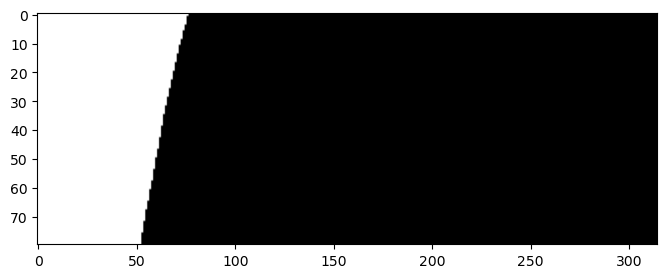

In [4]:

from gcode_expected_print_mask import gcode_expected_print_mask, parse_frame_xyz
x, y, z = parse_frame_xyz(TEST_IMAGE_PATH)
PX_PER_MM = 26.13       
local_mask_wl = ~gcode_expected_print_mask(x, y, z, theta_deg=26.2, px_to_mm=(1/PX_PER_MM))
plt.figure(figsize=(8, 3))
plt.imshow(local_mask_wl, cmap='gray', origin='upper', aspect='auto')

## Coarse scan


best offset: -28.0


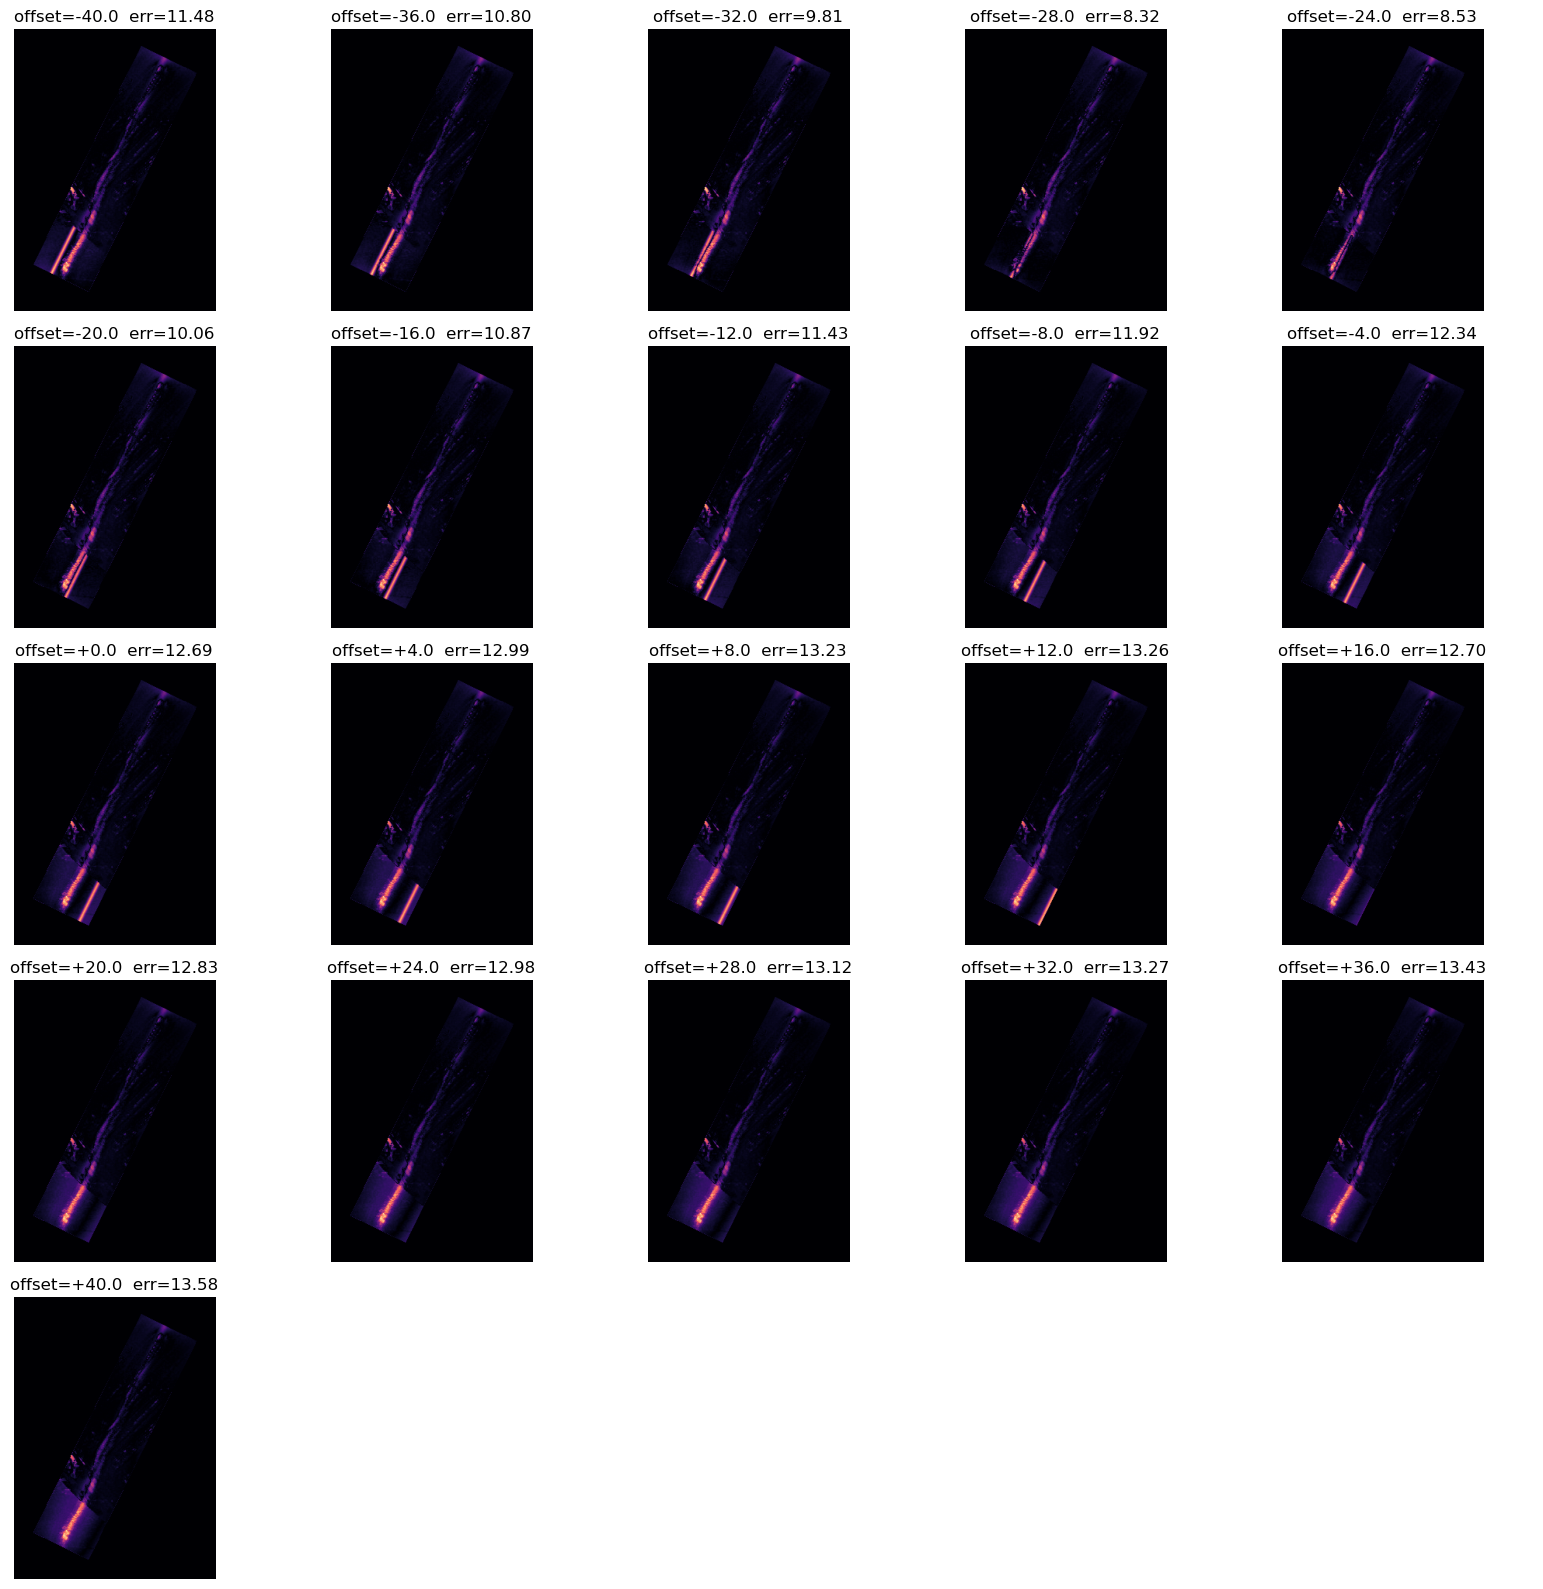

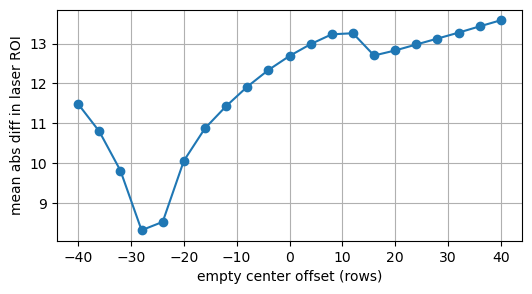

coarse best: -28.0


In [5]:

offsets, scores = scan_empty_offsets(local_mask_wl, offsets=np.arange(-40, 41, 4))

plt.figure(figsize=(6, 3))
plt.plot(offsets, scores, 'o-')
plt.xlabel('empty center offset (rows)')
plt.ylabel('mean abs diff in laser ROI')
plt.grid(True)
plt.show()

best = offsets[np.argmin(scores)]
print('coarse best:', best)


## Fine scan around the best coarse value


best offset: -26.0


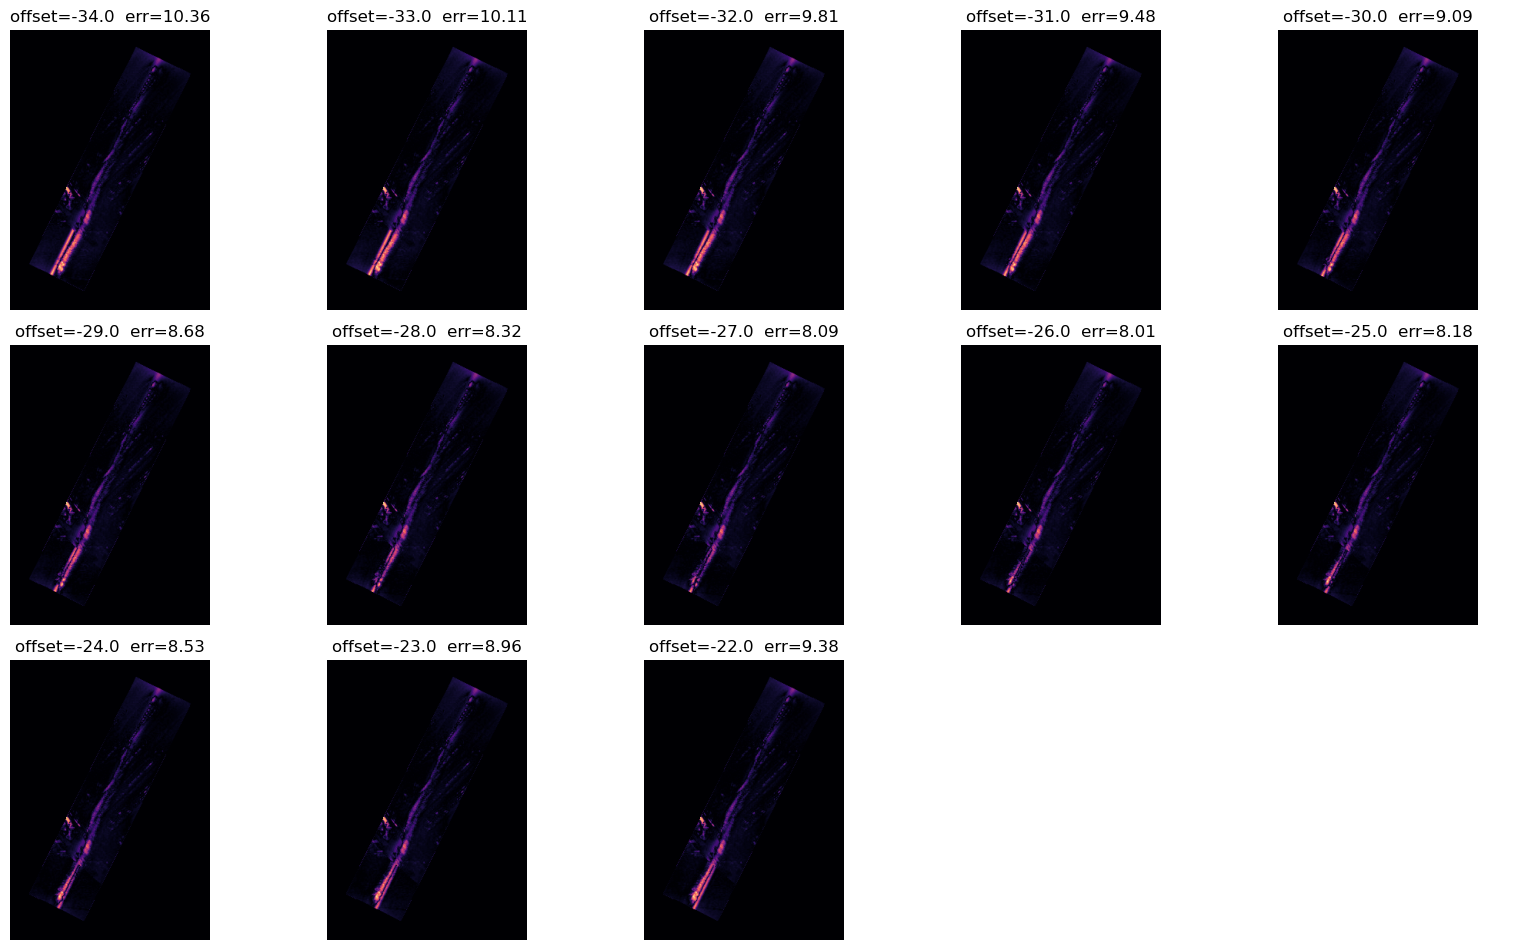

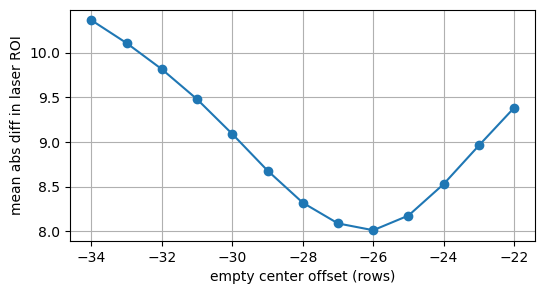

fine best: -26.0


In [6]:

offsets2, scores2 = scan_empty_offsets(
    local_mask_wl,
    offsets=np.arange(best - 6, best + 6.1, 1),
)

plt.figure(figsize=(6, 3))
plt.plot(offsets2, scores2, 'o-')
plt.xlabel('empty center offset (rows)')
plt.ylabel('mean abs diff in laser ROI')
plt.grid(True)
plt.show()

best2 = offsets2[np.argmin(scores2)]
print('fine best:', best2)


## Inspect one chosen offset


full center: 193.9351803058175
empty measured center: 225.99111050963674
empty rendered center: 199.99111050963674


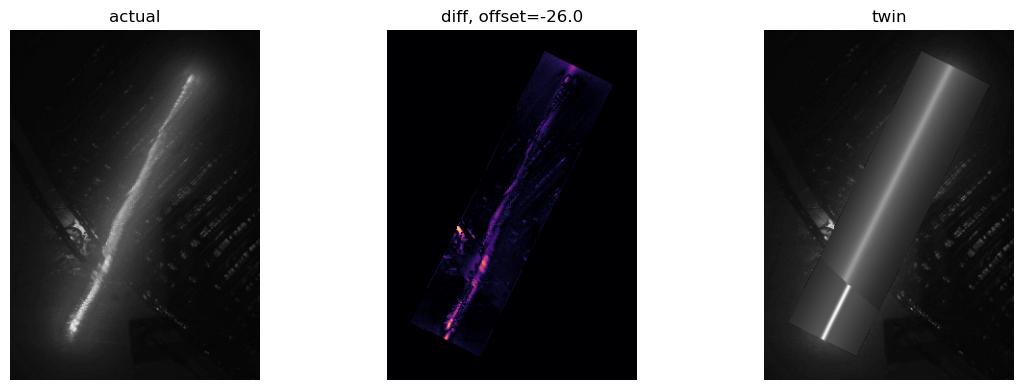

In [7]:

diff = show_empty_offset(local_mask_wl, offset_rows=best2)


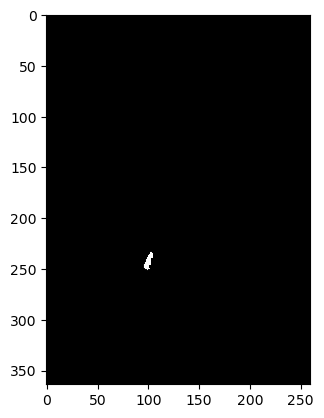

In [49]:
#threshold_otsu on the diff image to get a binary mask of the differences
from skimage.filters import threshold_yen
from skimage.morphology import remove_small_objects
diff= np.abs(diff)
t = threshold_yen(diff)
bin = np.zeros_like(diff, dtype=bool)
bin = diff > t
bin = remove_small_objects(bin, max_size=60, connectivity=10)
plt.imshow(bin, cmap='gray')


## Final usage


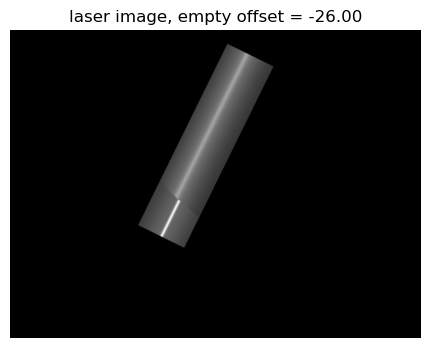

In [ ]:

EMPTY_CENTER_OFFSET_ROWS = float(best2)

laser_img = make_laser_image(
    local_mask_wl,
    EMPTY_TEMPLATE_PATH,
    FULL_TEMPLATE_PATH,
    mask_true='empty',
    empty_center_offset_rows=EMPTY_CENTER_OFFSET_ROWS,
)

plt.figure(figsize=(8, 4))
plt.imshow(laser_img, cmap='gray')
plt.axis('off')
plt.title(f'laser image, empty offset = {EMPTY_CENTER_OFFSET_ROWS:+.2f}')
plt.show()
